<a href="https://colab.research.google.com/github/ArtyomShabunin/SMOPA-26/blob/main/lesson_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://prana-system.com/files/110/rds_color_full.png" alt="tot image" width="300"  align="center"/> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<img src="https://mpei.ru/AboutUniverse/OficialInfo/Attributes/PublishingImages/logo1.jpg" alt="mpei image" width="200" align="center"/>
<img src="https://mpei.ru/Structure/Universe/tanpe/structure/tfhe/PublishingImages/tot.png" alt="tot image" width="100"  align="center"/>

---

# **Системы машинного обучения и предиктивной аналитики в тепловой и возобновляемой энергетике**  

# ***Практические занятия***


---

# Занятие №6
# Многоклассовая классификация методами машинного обучения
**25 марта 2026г.**

In [55]:
import numpy as np
import pandas as pd

from sklearn import preprocessing
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display, clear_output

from tqdm import tqdm


## Загрузка данных

In [56]:
import gdown
import warnings
warnings.filterwarnings('ignore')
# gdown.download('https://drive.google.com/uc?id=1j54o4pHTm3HvaYTEtv_i4hOJGy5yNeZZ', verify=False)

data = pd.read_parquet("./data_modes.gzip")

In [57]:
data.head()

,GTA1.DBinPU.Aldi,GTA1.DBinPU.Alvna,GTA1.DBinPU.Alzzo,GTA1.DBinPU.Bo,GTA1.DBinPU.DlPkf,GTA1.DBinPU.DlPtgft,GTA1.DBinPU.DlPvf,GTA1.DBinPU.fi,GTA1.DBinPU.hmGTD,GTA1.DBinPU.hmTG,...,increas_power_mode,decreas_power_mode,start_up_mode,shutdown_mode,stopped_state_mode,air_heating_mode,active_target_mode_count,target_is_conflict,target_is_unknown,target
2023-02-26 06:59:50,225.550000,-4.398000,-0.082000,101.044,113.088000,33.709000,0.200000,56.615000,442.64,444.536,...,False,False,False,False,False,False,1,False,False,full_power_mode
2023-02-26 07:00:00,225.610769,-4.327115,-0.089769,101.044,113.151231,33.709000,0.200000,56.615000,442.64,444.536,...,False,False,False,False,False,False,1,False,False,full_power_mode
2023-02-26 07:00:10,225.436897,-4.363724,-0.091000,101.044,113.039759,33.633586,0.200207,56.516103,442.64,444.536,...,False,False,False,False,False,False,1,False,False,full_power_mode
2023-02-26 07:00:20,225.710833,-4.306625,-0.093000,101.044,113.053458,33.506500,0.200750,56.376000,442.64,444.536,...,False,False,False,False,False,False,1,False,False,full_power_mode
2023-02-26 07:00:30,226.355000,-4.183118,-0.091500,101.044,113.730941,33.818529,0.200000,56.199353,442.64,444.536,...,False,False,False,False,False,False,1,False,False,full_power_mode


## Сформируем датасет для решения задачи многоклассовой классификации

Выберем сигналы которые будем использовать. Исключим все признаки на основании которых мы на предыдущем занятии выделяли целевые режимы.

In [58]:
use_columns = ['GTA1.DBinPU.Alzzo', 'GTA1.DBinPU.Bo', 'GTA1.DBinPU.DlPkf',
               'GTA1.DBinPU.DlPtgft', 'GTA1.DBinPU.DlPvf', 'GTA1.DBinPU.fi',
               'GTA1.DBinPU.hmGTD', 'GTA1.DBinPU.hmTG', 'GTA1.DBinPU.P1mvhTG',
               'GTA1.DBinPU.Pk', 'GTA1.DBinPU.Pmvh', 'GTA1.DBinPU.PmvhMOGTD',
               'GTA1.DBinPU.PmvhMOTG', 'GTA1.DBinPU.PmvyhMOGTD',
               'GTA1.DBinPU.PmvyhMOTG', 'GTA1.DBinPU.Prazrjag_navhode',
               'GTA1.DBinPU.Ptgpd', 'GTA1.DBinPU.Ptgvh', 'GTA1.DBinPU.Pvh',
               'GTA1.DBinPU.Pvyhlg', 'GTA1.DBinPU.Qtg', 'GTA1.DBinPU.Tk',
               'GTA1.DBinPU.Tn', 'GTA1.DBinPU.Tt', 'GTA1.DBinPU.Tvh1',
               'GTA1.DBinPU.Pzad']

X = data.loc[:,use_columns]

Сформируем отдельный целевой признак

In [59]:
data['target'] = data[[
    'full_power_mode', 'partial_power_mode',
    'increas_power_mode', 'decreas_power_mode', 'start_up_mode',
    'shutdown_mode', 'stopped_state_mode']].idxmax(axis=1)
y = data.loc[:, ['target']]

In [62]:
y.value_counts()

target            
full_power_mode       1045103
stopped_state_mode      26614
partial_power_mode       9547
shutdown_mode             347
start_up_mode             275
increas_power_mode        109
decreas_power_mode        103
Name: count, dtype: int64

### Деление на тестовую и тренировочную выборки


In [63]:
from sklearn.model_selection import train_test_split
# Разделяем с учетом дисбаланса классов
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [64]:
y_train.value_counts()

target            
full_power_mode       836082
stopped_state_mode     21291
partial_power_mode      7638
shutdown_mode            278
start_up_mode            220
increas_power_mode        87
decreas_power_mode        82
Name: count, dtype: int64

In [65]:
y_test.value_counts()

target            
full_power_mode       209021
stopped_state_mode      5323
partial_power_mode      1909
shutdown_mode             69
start_up_mode             55
increas_power_mode        22
decreas_power_mode        21
Name: count, dtype: int64

Видно, что датасет сильно несбалансирован.
При такой несбалансорованности модели будут плохо обучаеться на редких классах.
Алгоритм может игнорировать малочисленные классы, потому что минимизация ошибки будет достигаться за счет предсказания большинства.
Например, если модель всегда предсказывает full_power_mode, она все равно получит высокую точность.

<!-- попробуем его немного выровнять путем сокращения данных по наиболее часто встречающимся режимам -->

### Балансировка данных
**Oversampling (увеличение малых классов)**  
   - Повторение существующих редких примеров или их генерация.  
   - **SMOTE (Synthetic Minority Over-sampling Technique)** – создает новые точки малочисленных классов, используя линейные комбинации соседних точек.  

**Undersampling (уменьшение частых классов)**  
- Удаление случайных примеров из большинства классов.  

**Комбинация Oversampling + Undersampling**  
   - Часто лучше сначала **уменьшить большие**, а затем **увеличить малые классы**.  

In [66]:
!pip install imblearn

#### Undersampling

In [67]:
from imblearn.under_sampling import RandomUnderSampler
sampling_strategy = {
    "full_power_mode": 1000,
    "stopped_state_mode": 1000,
    "partial_power_mode": 1000
}
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [68]:
y_train_resampled.value_counts()

target            
full_power_mode       1000
partial_power_mode    1000
stopped_state_mode    1000
shutdown_mode          278
start_up_mode          220
increas_power_mode      87
decreas_power_mode      82
Name: count, dtype: int64

In [69]:
# Тестовую выборку НЕ ресемплируем, чтобы метрики отражали реальное распределение классов
X_test_eval = X_test.copy()
y_test_eval = y_test.copy()


In [70]:
y_test_eval.value_counts()


target            
full_power_mode       209021
stopped_state_mode      5323
partial_power_mode      1909
shutdown_mode             69
start_up_mode             55
increas_power_mode        22
decreas_power_mode        21
Name: count, dtype: int64

#### Oversampling

In [71]:
from imblearn.over_sampling import SMOTE
X_train_resampled, y_train_resampled = SMOTE().fit_resample(X_train_resampled, y_train_resampled)

In [72]:
y_train_resampled.value_counts()

target            
decreas_power_mode    1000
full_power_mode       1000
increas_power_mode    1000
partial_power_mode    1000
shutdown_mode         1000
start_up_mode         1000
stopped_state_mode    1000
Name: count, dtype: int64

### Нормализация или стандартизация данных

In [73]:
# scaler = preprocessing.MinMaxScaler() # нормализация данных
scaler = preprocessing.StandardScaler() # стандартизация данных

X_train_resampled_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_resampled),
    columns=X_train_resampled.columns,
    index=X_train_resampled.index)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_eval),
    columns=X_test_eval.columns,
    index=X_test_eval.index)

X_train_resampled_scaled.describe()


,GTA1.DBinPU.Alzzo,GTA1.DBinPU.Bo,GTA1.DBinPU.DlPkf,GTA1.DBinPU.DlPtgft,GTA1.DBinPU.DlPvf,GTA1.DBinPU.fi,GTA1.DBinPU.hmGTD,GTA1.DBinPU.hmTG,GTA1.DBinPU.P1mvhTG,GTA1.DBinPU.Pk,...,GTA1.DBinPU.Ptgpd,GTA1.DBinPU.Ptgvh,GTA1.DBinPU.Pvh,GTA1.DBinPU.Pvyhlg,GTA1.DBinPU.Qtg,GTA1.DBinPU.Tk,GTA1.DBinPU.Tn,GTA1.DBinPU.Tt,GTA1.DBinPU.Tvh1,GTA1.DBinPU.Pzad
count,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,...,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03
mean,8.120488e-18,-4.811389e-15,-1.624098e-16,-4.872293e-17,1.624098e-16,-1.299278e-16,-5.785848e-16,9.744586e-16,4.385064e-16,-1.948917e-16,...,1.299278e-16,-1.299278e-16,-9.257357e-16,-2.273737e-16,-4.872293e-17,-9.744586e-17,1.055663e-16,-3.573015e-16,-6.496391e-17,-1.948917e-16
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,...,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.392977e-01,-3.573022e+00,-1.233404e+00,-1.222813e+00,-1.236095e+00,-1.747683e+00,-1.560433e+00,-1.683707e+00,-2.421971e+00,-1.208379e+00,...,-1.425999e+00,-1.543212e+00,-2.015220e+00,-1.076176e+00,-1.222476e+00,-1.342988e+00,-3.530632e+00,-1.520934e+00,-3.952374e+00,-1.107652e+00
25%,-1.263258e-01,-8.363464e-01,-1.207023e+00,-1.119775e+00,-1.179178e+00,-8.227511e-01,-9.800775e-01,-8.270909e-01,1.529213e-01,-1.201691e+00,...,-1.422180e+00,-1.540813e+00,-1.037517e+00,-9.705845e-01,-1.222406e+00,-1.217287e+00,-7.638304e-01,-1.385613e+00,-6.408532e-01,-1.107652e+00
50%,-1.234112e-01,2.380952e-01,8.291650e-02,-5.431278e-02,2.199769e-01,-2.107368e-01,-1.954730e-01,5.951869e-02,4.119316e-01,4.156244e-01,...,6.395149e-01,6.186029e-01,-1.784751e-03,-2.542335e-01,2.811024e-01,5.339755e-01,-1.130164e-01,5.284938e-01,-4.940339e-02,2.138469e-01
75%,-1.198732e-01,7.096212e-01,9.063861e-01,9.896857e-01,9.445944e-01,6.617526e-01,7.310773e-01,6.351602e-01,5.161633e-01,1.014218e+00,...,7.330029e-01,6.787940e-01,9.360265e-01,1.081719e+00,9.500588e-01,8.892148e-01,6.866922e-01,7.615842e-01,8.324587e-01,1.124902e+00
max,8.423232e+00,2.856668e+00,1.753590e+00,7.752596e+00,1.579409e+00,2.478672e+00,2.674932e+00,2.433688e+00,1.000348e+00,1.156436e+00,...,9.218533e-01,8.434486e-01,1.298237e+00,1.725058e+00,1.654578e+00,1.256632e+00,2.465462e+00,1.269614e+00,2.375822e+00,1.203930e+00


Инициализируем переменные для дальнейшего сравнения моделей

In [74]:
accuracy_classifier = {}
precision_classifier = {}
recall_classifier = {}
f1_classifier = {}


## Метод опорных векторов

Метод опорных векторов изначально предназначен для бинарной классификации, однако существуют способы адаптации его для решения задач многоклассовой классификации.  

Один из таких подходов — стратегия **"один против остальных"** (*one-versus-the-rest*, OvR), также известная как **"один против всех"** (*one-versus-all*, OvA). В этом случае обучается $N$ бинарных классификаторов, по одному для каждого класса. Во время предсказания выбирается класс с наивысшим значением функции принятия решения.  

Другой подход — **"один против одного"** (*one-versus-one*, OvO), при котором для каждой пары классов обучается отдельный бинарный классификатор. Таким образом, для $N$ классов требуется обучить $\frac{N(N - 1)}{2}$ классификаторов. Преимущество этого метода в том, что каждый классификатор тренируется только на подмножестве данных, относящихся к двум соответствующим классам.  

Метод опорных векторов плохо масштабируется при увеличении объема обучающего набора, поэтому стратегия **OvO часто предпочтительнее**: проще и быстрее обучить множество небольших классификаторов, чем несколько моделей, использующих полный набор данных. Однако для большинства бинарных алгоритмов стратегия **OvR является более естественной**, поскольку в ней каждая модель учитывает все данные и их принадлежность к конкретному классу.  

### Рекомендации по выбору стратегии:
- **OvO**  
  - Лучше для моделей, плохо масштабируемых с ростом данных (например, SVM с нелинейными ядрами).  
  - Эффективна при **большом количестве классов**, так как каждый классификатор использует только малую часть данных.  
  - Может быть избыточна при небольшом числе классов.  

- **OvR**   
  - Применяется, когда **классов немного**, чтобы избежать чрезмерного количества моделей.  
  - Может работать лучше, если один класс является **доминирующим** (например, задачи выявления аномалий).  

Выбор стратегии зависит от конкретных данных и требований к модели. Если данных много и используется метод SVM, чаще всего предпочтительнее OvO. Если же данных не так много или алгоритм легко масштабируется, стоит попробовать OvR.

In [75]:
kernel = widgets.Dropdown(
    options=['linear', 'poly', 'rbf', 'sigmoid'],
    value='rbf',
    description='Kernel:',
    disabled=False,
)

strategy = widgets.Dropdown(
    options=['ovo', 'ovr'],
    value='ovr',
    description='Strategy:',
    disabled=False,
)

widgets.VBox([
    widgets.Label('Тип ядра, который будет использоваться в алгоритме'),
    kernel,
    widgets.Label('Стратегия'),
    strategy])

In [86]:
svm_clf = SVC(gamma="scale", random_state=42,
              decision_function_shape=strategy.value,
              kernel = kernel.value)
svm_clf.fit(X_train_resampled_scaled, y_train_resampled)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [87]:
some_indexes = y_test_eval.groupby('target').sample(n=1, random_state=42).index
X_some_modes = X_test_scaled.loc[some_indexes]
y_some_modes = y_test_eval.loc[some_indexes]

for target, predict in zip(y_some_modes.values, svm_clf.predict(X_some_modes)):
    print(f"Истина - {target[0]} >>> {predict} - предсказание {target[0] == predict}")


Истина - decreas_power_mode >>> full_power_mode - предсказание False
Истина - full_power_mode >>> full_power_mode - предсказание True
Истина - increas_power_mode >>> full_power_mode - предсказание False
Истина - partial_power_mode >>> partial_power_mode - предсказание True
Истина - shutdown_mode >>> start_up_mode - предсказание False
Истина - start_up_mode >>> start_up_mode - предсказание True
Истина - stopped_state_mode >>> stopped_state_mode - предсказание True


Метод **`decision_function()`** в `SVC` из `sklearn` возвращает оценку степени принадлежности объекта к определенному классу. Эта оценка называется **отступом (margin)** и представляет собой расстояние до разделяющей гиперплоскости в пространстве признаков.  

**Для многоклассовой классификации** (`n_classes > 2`):  
   - Если используется стратегия **"Один-против-одного" (OvO, по умолчанию в `SVC`)**, то метод возвращает массив размерности `(n_samples, n_classes * (n_classes - 1) / 2)`, где каждая колонка соответствует предсказанному отступу для одной из пар классов. Итоговый класс определяется голосованием.  
   - Если используется стратегия **"Один-против-остальных" (OvR, при использовании `OneVsRestClassifier`)**, то метод возвращает массив размерности `(n_samples, n_classes)`, где каждое значение — это отступ для соответствующего класса.

In [88]:
some_mode_scores = svm_clf.decision_function(X_some_modes)
print(some_mode_scores)

[[-0.48357867  1.43276579  1.5150715   1.9383653   1.33858472  1.00484063
   1.64677766  1.92961829  1.096281    1.1319293   0.99382223  1.04978382
   1.89974806  1.56269366  0.93234437  1.66697325  1.25016052  0.93641
  -0.04989248  0.09069207  0.40981316]
 [-1.22616117  0.27903976  0.36281876  2.08264754  1.00086371  1.07200874
   1.27151717  1.22483337  1.12361524  1.1027566   1.14849522  0.51844669
   1.72956774  0.36847734  0.99682249  2.04204937  0.85322011  1.01999962
  -1.12169502  0.05454253  0.92000176]
 [-1.37273288 -1.01315227  1.11156738  1.99766326  1.12991697  1.13711984
   0.2412817   1.30104322  1.04909995  1.08514653  1.10993733  1.00290964
   1.49043894  1.12334875  1.11803361  1.82406099  1.06502262  1.07278279
  -0.75080552  0.12051733  0.7692716 ]
 [ 1.53625402  1.65131752 -0.98503092  1.41726737  1.23277676  1.10936318
   0.20305871 -1.28564007  1.14665825  1.09024815  1.11673559 -1.50291432
   1.31577421  1.4884154   1.03288826  1.70757385  1.46382089  1.0816422

In [89]:
pd.concat([pd.DataFrame(some_mode_scores, columns=svm_clf.classes_), y_some_modes.reset_index(drop=True)], axis=1)

ValueError: Shape of passed values is (7, 21), indices imply (7, 7)

### Анализ качества модели опорных векторов

In [90]:
y_test_pred_svm = svm_clf.predict(X_test_scaled)


#### Матрица неточностей

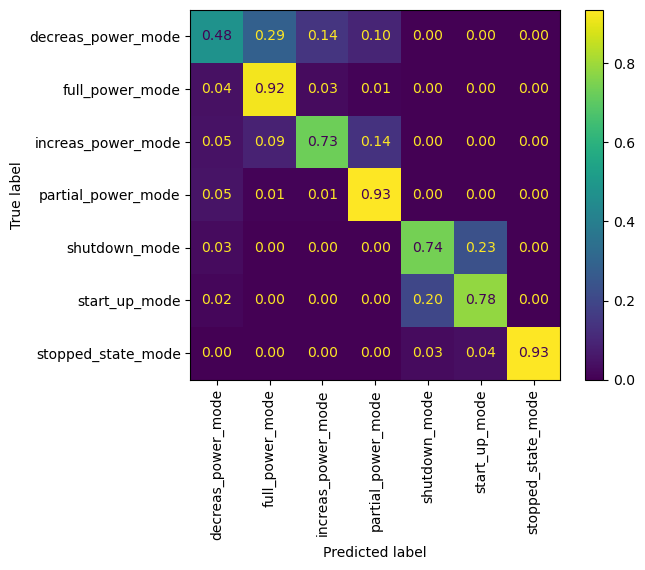

In [91]:
conf_mat = confusion_matrix(y_test_eval.squeeze(), y_test_pred_svm, normalize='true')
ConfusionMatrixDisplay(conf_mat, display_labels=svm_clf.classes_).plot(values_format='.2f')
plt.xticks(rotation=90)
plt.show()


#### Accuracy

In [92]:
accuracy_classifier['svm'] = accuracy_score(y_test_eval.squeeze(), y_test_pred_svm)


#### Precision и recall

In [93]:
precision_classifier['svm'] = precision_score(y_test_eval.squeeze(), y_test_pred_svm, average='macro', zero_division=np.nan)
recall_classifier['svm'] = recall_score(y_test_eval.squeeze(), y_test_pred_svm, average='macro', zero_division=np.nan)


#### F1

In [94]:
f1_classifier['svm'] = f1_score(y_test_eval.squeeze(), y_test_pred_svm, average='macro', zero_division=np.nan)

#### Значения метрик

In [95]:
print(f"accuracy - {accuracy_classifier['svm']*100:0.2f}%")
print(f"precision - {precision_classifier['svm']*100:0.2f}%")
print(f"recall - {recall_classifier['svm']*100:0.2f}%")
print(f"F1 - {f1_classifier['svm']*100:0.2f}%")


accuracy - 91.91%
precision - 39.57%
recall - 78.72%
F1 - 43.68%


## Метод ближайших соседей (K-Nearest Neighbors, KNN)


**Метод k-ближайших соседей (KNN)** – это простой и эффективный алгоритм **классификации** и **регрессии**, основанный на **поиске ближайших точек** в пространстве признаков.  

**Основная идея:**  
1. Для нового объекта **ищутся K ближайших точек** (соседей) в обучающей выборке.  
2. Класс объекта определяется **по большинству** среди соседей.   

<!-- ![knn image](https://loginom.ru/sites/default/files/blogpost-files/knn-working.svg) -->
<img src="https://loginom.ru/sites/default/files/blogpost-files/knn-working.svg" alt="knn image" width="600"  align="center"/>

---

**Как работает KNN?**  

**Выбираем количество соседей (K)**  
- Маленькое K → модель **чувствительна** к шуму (может переобучаться).  
- Большое K → модель становится **более устойчивой**, но может терять точность.  

**Вычисляем расстояния между точками**  
- **Евклидово расстояние** (стандартный вариант):  
$$ d(A, B) = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2} $$
- Можно использовать и другие метрики: **Манхэттенское, Чебышёва**.  

**Определяем класс нового объекта**  
- Берем K ближайших точек и **голосуем за класс** (большинство решает).  
- Если **регрессия** – усредняем значения.  

---

**Преимущества и недостатки KNN**  

**Плюсы:**  
**Простота** – не требует сложного обучения.    
**Хорошо работает при малых данных**.  

**Минусы:**  
**Медленный при больших данных** – O(N) сложность поиска соседей.  
**Чувствителен к шуму** при малых K.  
**Плохо работает с высокой размерностью**.  

---

Метод ближайших соседей **хорош для небольших данных** и **прост в реализации**, но **плохо масштабируется**.  
Лучше работает при **малом количестве признаков** и **нормализованных данных**.

In [96]:
n_neighbors = widgets.IntSlider(
    value=5, min=1, max=20, step=1, description="Число соседей:")
display(n_neighbors)

IntSlider(value=5, description='Число соседей:', max=20, min=1)

In [97]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=n_neighbors.value)
knn_clf.fit(X_train_resampled_scaled, y_train_resampled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [98]:
some_indexes = y_test_eval.groupby('target').sample(n=1, random_state=42).index
X_some_modes = X_test_scaled.loc[some_indexes]
y_some_modes = y_test_eval.loc[some_indexes]

for target, predict in zip(y_some_modes.values, knn_clf.predict(X_some_modes)):
    print(f"Истина - {target[0]} >>> {predict} - предсказание")


Истина - decreas_power_mode >>> decreas_power_mode - предсказание
Истина - full_power_mode >>> full_power_mode - предсказание
Истина - increas_power_mode >>> increas_power_mode - предсказание
Истина - partial_power_mode >>> partial_power_mode - предсказание
Истина - shutdown_mode >>> start_up_mode - предсказание
Истина - start_up_mode >>> start_up_mode - предсказание
Истина - stopped_state_mode >>> stopped_state_mode - предсказание


Метод **`predict_proba()`** в `KNeighborsClassifier` предоставляет **вероятности** принадлежности объекта к каждому классу. Эти вероятности можно интерпретировать как **"уверенность"** модели.

Метод `predict_proba()` в **KNN** может давать высокие вероятности, даже если предсказание неверное, особенно если количество соседей мало или данные несбалансированы. Рекомендуется проводить настройку параметра `k`, балансировать данные и, в случае необходимости, рассматривать другие методы классификации.

In [99]:
pd.DataFrame(knn_clf.predict_proba(X_some_modes), columns=knn_clf.classes_)

,decreas_power_mode,full_power_mode,increas_power_mode,partial_power_mode,shutdown_mode,start_up_mode,stopped_state_mode
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.2,0.8,0.0
5,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Для автоматического подбора гиперпараметров для модели **K ближайших соседей (KNN)** в Python можно использовать **GridSearchCV** или **RandomizedSearchCV** из библиотеки **scikit-learn**. Эти инструменты помогут подобрать оптимальные значения гиперпараметров, таких как количество соседей (k), метрика расстояния, алгоритм поиска ближайших соседей и другие параметры.

1. **Использование `GridSearchCV`**:
   - `GridSearchCV` выполняет **поиск по сетке**, проверяя все возможные комбинации заданных гиперпараметров. Это даёт гарантию, что вы найдете наилучшие параметры, но может занять много времени для больших наборов данных и большого количества параметров.

2. **Использование `RandomizedSearchCV`**:
   - `RandomizedSearchCV` выполняет **случайный поиск** по заданному пространству гиперпараметров, что может быть быстрее, чем полный перебор, особенно если пространство поиска большое.

### Ключевые параметры:
- **`n_neighbors`**: количество ближайших соседей, которое будет использовать модель для классификации.
- **`weights`**: функция веса, которая влияет на то, как рассчитываются "веса" соседей. Может быть:
  - `'uniform'`: все соседи имеют одинаковый вес.
  - `'distance'`: соседи взвешиваются в зависимости от расстояния.
- **`metric`**: метрика расстояния, например:
  - `'euclidean'` — евклидово расстояние.
  - `'manhattan'` — манхэттенское расстояние.
  - `'chebyshev'` — расстояние Чебышева.
- **`cv`**: количество фолдов для кросс-валидации.
- **`n_jobs`**: количество ядер процессора, которое будет использоваться для параллельных вычислений (например, `-1` — для использования всех доступных ядер).

**Кросс-валидация (Cross-Validation, CV)** – это метод оценки качества модели, при котором данные **разбиваются на несколько частей (фолдов)**, и модель обучается на одной части, а тестируется на другой.  

---

**Как работает кросс-валидация?**  
1. Данные **разбиваются** на **K частей (фолдов)**.  
2. Модель **K раз** обучается и тестируется:  
   - **Обучение** – на \( K-1 \) частях.  
   - **Тестирование** – на оставшейся части.  
3. Итоговая метрика – **среднее значение по K фолдам**.  

<img src="https://nl.mathworks.com/discovery/cross-validation/_jcr_content/mainParsys/image.adapt.full.medium.jpg/1718274808277.jpg" alt="rf image" width="600"  align="center"/>

#### GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline

# Пайплайн без утечек: ресемплинг + масштабирование внутри каждого CV-фолда
knn_grid_pipeline = Pipeline([
    ('under', RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('scaler', preprocessing.StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan', 'chebyshev'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=knn_grid_pipeline, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=2)
%time grid_search.fit(X_train, y_train.squeeze())

print("Лучшие параметры:", grid_search.best_params_)
best_knn_grid = grid_search.best_estimator_
print("Точность на тестовой выборке:", best_knn_grid.score(X_test_eval, y_test_eval.squeeze()))


#### RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline

# Пайплайн без утечек: ресемплинг + масштабирование внутри каждого CV-фолда
knn_pipeline = Pipeline([
    ('under', RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('scaler', preprocessing.StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_dist = {
    'model__n_neighbors': np.arange(1, 21),
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan', 'chebyshev'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=knn_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
)

%time random_search.fit(X_train, y_train.squeeze())

print("Лучшие параметры:", random_search.best_params_)
best_knn = random_search.best_estimator_
print("Точность на тестовой выборке:", best_knn.score(X_test_eval, y_test_eval.squeeze()))


Выбор **n_neighbors = 1** может быть оптимален, если данные достаточно чисты и между классами есть чёткое разделение. В таком случае ближайший сосед может быть достаточно хорош для точного предсказания, и использование одного соседа может быть достаточно эффективным.

### Анализ качества модели ближайших соседей

In [115]:
y_test_pred_knn = best_knn.predict(X_test_eval)


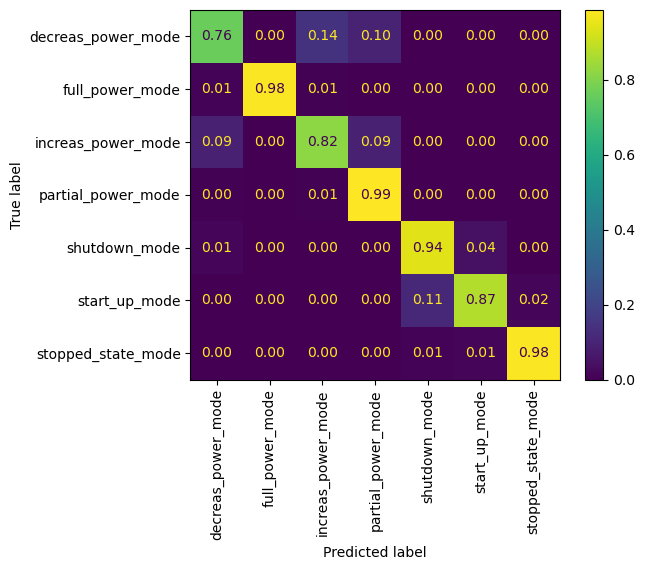

In [116]:
conf_mat = confusion_matrix(y_test_eval.squeeze(), y_test_pred_knn, normalize='true')
ConfusionMatrixDisplay(conf_mat, display_labels=svm_clf.classes_).plot(values_format='.2f')
plt.xticks(rotation=90)
plt.show()


#### Accuracy

In [117]:
accuracy_classifier['knn'] = accuracy_score(y_test_eval.squeeze(), y_test_pred_knn)


#### Precision и recall

In [118]:
precision_classifier['knn'] = precision_score(y_test_eval.squeeze(), y_test_pred_knn, average='macro', zero_division=np.nan)
recall_classifier['knn'] = recall_score(y_test_eval.squeeze(), y_test_pred_knn, average='macro', zero_division=np.nan)


#### F1

In [119]:
f1_classifier['knn'] = f1_score(y_test_eval.squeeze(), y_test_pred_knn, average='macro', zero_division=np.nan)


#### Значения метрик

In [120]:
print(f"accuracy - {accuracy_classifier['knn']*100:0.2f}%")
print(f"precision - {precision_classifier['knn']*100:0.2f}%")
print(f"recall - {recall_classifier['knn']*100:0.2f}%")
print(f"F1 - {f1_classifier['knn']*100:0.2f}%")


accuracy - 97.99%
precision - 48.78%
recall - 90.57%
F1 - 54.26%


## Случайный лес (Random Forest)

**Случайный лес (Random Forest)** – это ансамблевый алгоритм машинного обучения, который строит **множество деревьев решений** и объединяет их предсказания. Он используется как для **классификации**, так и для **регрессии**.  

**Основная идея** – создать несколько деревьев решений и усреднять их предсказания, чтобы модель была **более точной и устойчивой**.

<img src="https://victorzhou.com/media/random-forest-post/random-forest.png" alt="rf image" width="800"  align="center"/>

---

**Как работает случайный лес?**  
**Создание множества деревьев решений**  
- Каждое дерево строится на **случайной подвыборке** данных (bagging).  
- Для каждого разбиения в узле дерева выбирается **случайное подмножество признаков**.  

**Обучение деревьев независимо друг от друга**  
- В отличие от градиентного бустинга, деревья **не зависят друг от друга**.  
- Это делает алгоритм **быстрым в обучении** и **устойчивым к переобучению**.  

**Объединение предсказаний**  
- В **классификации** – голосование большинства (majority voting).  

---

**Когда использовать Random Forest?**  
Когда нужна **высокая точность**.  
Когда данные **шумные** или **содержат выбросы**.  
Когда важна **устойчивость модели** к переобучению.  
Когда нужно **оценить важность признаков**.  

**Когда НЕ использовать?**  
Если нужны **интерпретируемые модели** – сложно понять, как именно модель принимает решение.  
Если важна **скорость предсказаний** – например, для реального времени.  

---

**Random Forest** – мощный алгоритм, который отлично работает на большинстве задач машинного обучения. Он особенно полезен, когда нужна **высокая точность**, а данные **сложные и шумные**.

In [101]:
n_estimators = widgets.IntSlider(
    value=100, min=1, max=500, step=1, description="Число деревьев:")
display(n_estimators)

IntSlider(value=100, description='Число деревьев:', max=500, min=1)

In [104]:
forest_clf = RandomForestClassifier(n_estimators=n_estimators.value, random_state=42)
forest_clf.fit(X_train_resampled_scaled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",398
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [105]:
some_indexes = y_test_eval.groupby('target').sample(n=1, random_state=42).index
X_some_modes = X_test_scaled.loc[some_indexes]
y_some_modes = y_test_eval.loc[some_indexes]

for target, predict in zip(y_some_modes.values, forest_clf.predict(X_some_modes)):
    print(f"Истина - {target[0]} >>> {predict} - предсказание")


Истина - decreas_power_mode >>> decreas_power_mode - предсказание
Истина - full_power_mode >>> full_power_mode - предсказание
Истина - increas_power_mode >>> increas_power_mode - предсказание
Истина - partial_power_mode >>> partial_power_mode - предсказание
Истина - shutdown_mode >>> shutdown_mode - предсказание
Истина - start_up_mode >>> start_up_mode - предсказание
Истина - stopped_state_mode >>> stopped_state_mode - предсказание


Метод **`predict_proba()`** в Random Forest предоставляет вероятности для каждого класса. Эти вероятности можно интерпретировать как уверенность модели в предсказаниях. Чем выше вероятность для предсказанного класса, тем более уверена модель в своём решении.

In [106]:
pd.DataFrame(forest_clf.predict_proba(X_some_modes), columns=forest_clf.classes_)

,decreas_power_mode,full_power_mode,increas_power_mode,partial_power_mode,shutdown_mode,start_up_mode,stopped_state_mode
0,0.932161,0.057789,0.010050,0.00000,0.000000,0.000000,0.000000
1,0.077889,0.891960,0.020101,0.01005,0.000000,0.000000,0.000000
2,0.000000,0.065327,0.934673,0.00000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.00000,0.668342,0.331658,0.000000
5,0.000000,0.000000,0.000000,0.00000,0.042714,0.924623,0.032663
6,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000


#### Подбор гиперпараметров с использованием `RandomizedSearchCV`

В этом блоке для `RandomForestClassifier` подбираются следующие гиперпараметры:

- `n_estimators` — количество деревьев в лесу.
- `max_depth` — максимальная глубина каждого дерева (`None` означает без ограничения).
- `min_samples_split` — минимальное число объектов, необходимое для разделения узла.
- `min_samples_leaf` — минимальное число объектов в листе.
- `model__max_features` — число признаков, рассматриваемых при поиске лучшего разбиения (`sqrt` или `log2`).
- `model__bootstrap` — использовать ли bootstrap-выборки при построении деревьев.


In [107]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('under', RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

param_dist = {
    'model__n_estimators': np.arange(50, 500, 50),
    'model__max_depth': [None, 10, 20, 30, 40],
    'model__min_samples_split': np.arange(2, 20, 2),
    'model__min_samples_leaf': np.arange(1, 20, 2),
    'model__max_features': ['sqrt', 'log2'],
    'model__bootstrap': [True, False],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
)

random_search.fit(X_train, y_train.squeeze())

print("Лучшие параметры:", random_search.best_params_)
best_rf = random_search.best_estimator_
print("Точность на тестовой выборке:", best_rf.score(X_test_eval, y_test_eval.squeeze()))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры: {'model__n_estimators': np.int64(300), 'model__min_samples_split': np.int64(6), 'model__min_samples_leaf': np.int64(1), 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__bootstrap': False}
Точность на тестовой выборке: 0.9932307550133999


### Анализ качества модели случайного леса

In [108]:
y_test_pred_forest = best_rf.predict(X_test_eval)


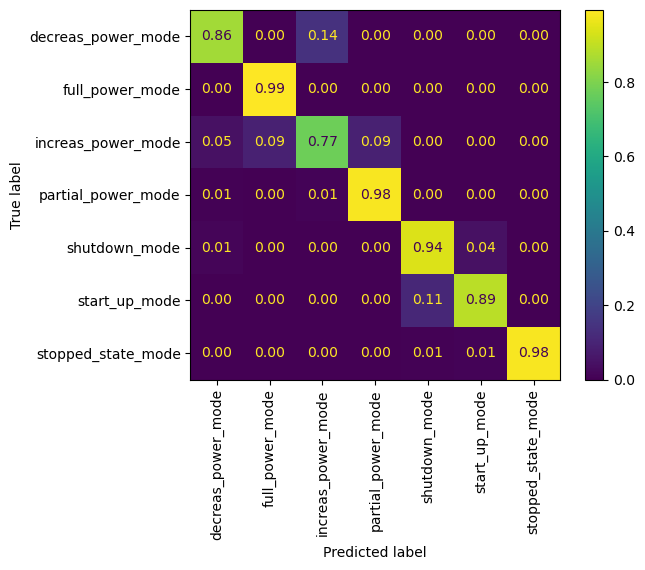

In [109]:
conf_mat = confusion_matrix(y_test_eval.squeeze(), y_test_pred_forest, normalize='true')
ConfusionMatrixDisplay(conf_mat, display_labels=svm_clf.classes_).plot(values_format='.2f')
plt.xticks(rotation=90)
plt.show()


#### Accuracy

In [110]:
accuracy_classifier['forest'] = accuracy_score(y_test_eval.squeeze(), y_test_pred_forest)


#### Precision и recall

In [111]:
precision_classifier['forest'] = precision_score(y_test_eval.squeeze(), y_test_pred_forest, average='macro', zero_division=np.nan)
recall_classifier['forest'] = recall_score(y_test_eval.squeeze(), y_test_pred_forest, average='macro', zero_division=np.nan)


#### F1

In [112]:
f1_classifier['forest'] = f1_score(y_test_eval.squeeze(), y_test_pred_forest, average='macro', zero_division=np.nan)

#### Значения метрик

In [113]:
print(f"accuracy - {accuracy_classifier['forest']*100:0.2f}%")
print(f"precision - {precision_classifier['forest']*100:0.2f}%")
print(f"recall - {recall_classifier['forest']*100:0.2f}%")
print(f"F1 - {f1_classifier['forest']*100:0.2f}%")


accuracy - 99.32%
precision - 52.33%
recall - 91.76%
F1 - 57.54%


## Сравнение

In [121]:
df = pd.DataFrame(
    [precision_classifier, recall_classifier, f1_classifier, accuracy_classifier],
    index=['Precision', 'Recall', 'F1-score', 'Accuracy'])
df

,svm,forest,knn
Precision,0.395747,0.523318,0.487847
Recall,0.787227,0.917591,0.905656
F1-score,0.436784,0.575403,0.542572
Accuracy,0.919120,0.993231,0.979854
